In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy
import Corrfunc

from scipy.optimize import curve_fit
from Corrfunc.theory import xi

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [10]:

odir = "ps_data"
with open(f"{odir}/random_test/test_Nmesh100.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal100 = pickle.load(f)
print("shotnoise", Pk_gal100.attrs["shotnoise"])

shotnoise 8.615124999999995


In [18]:

odir = "ps_data"
with open(f"{odir}/random_test/meshdata_Nmesh100.pickle", "rb") as f:
    mesh100 = pickle.load(f)

In [61]:
with open(f"{odir}/random_test/test_Nmesh500.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal500 = pickle.load(f)
print("shotnoise", Pk_gal500.attrs["shotnoise"])

shotnoise 8.615125


In [25]:

odir = "ps_data"
with open(f"{odir}/random_test/meshdata_Nmesh500.pickle", "rb") as f:
    mesh500 = pickle.load(f)

In [62]:
with open(f"{odir}/random_test/test_Nmesh50.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal50 = pickle.load(f)
print("shotnoise", Pk_gal50.attrs["shotnoise"])

shotnoise 8.615124999999995


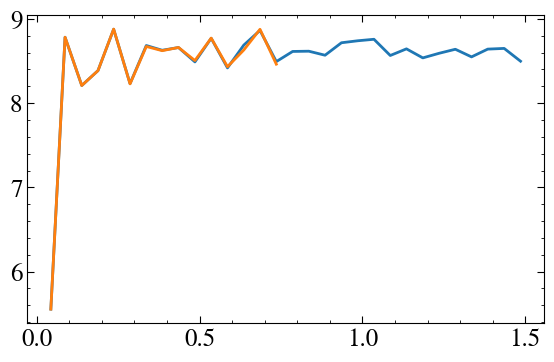

In [66]:
#plt.plot(Pk_gal500["k"], Pk_gal500["power"].real)
plt.plot(Pk_gal100["k"], Pk_gal100["power"].real)
plt.plot(Pk_gal50["k"], Pk_gal50["power"].real)

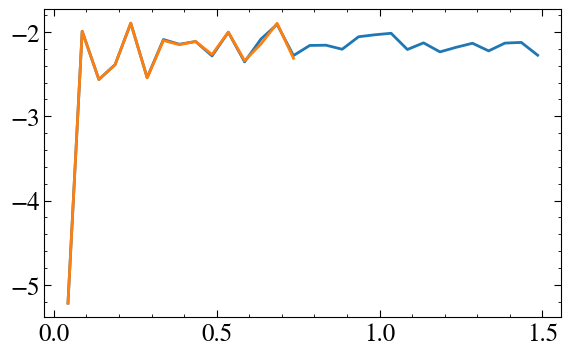

In [101]:
plt.plot(Pk_gal100["k"], Pk_gal100["power"].real-shot100)
plt.plot(Pk_gal50["k"], Pk_gal50["power"].real-shot100)

In [97]:
def vox_shotnoise(mesh):
    vol = (205**3)
    w_bar = nhalo/vol
    return vol*np.sum(mesh**2)/np.sum(mesh)**2

In [98]:
one_plus_delta100 = create_mesh(100)
shot100 = vox_shotnoise(one_plus_delta100.value+1)

one_plus_delta50 = create_mesh(50)
shot50 = vox_shotnoise(one_plus_delta50.value+1)

In [102]:
delta500 = create_mesh(500)
shot500 = vox_shotnoise(delta500.value)

In [99]:
print(shot50)
print(shot100)

71.073239142625
10.771863123542042


In [104]:
print(shot500)

8.68583096169183


In [76]:
print(nhalo)
print(50**3)
print(100**3)

1000000
125000
1000000


0.9575973650991716
0.14513349706227865


In [24]:
mesh100.shape

(25, 15, 100)

In [31]:
tng_data1 = np.loadtxt("halo_exclusion/random_seed0.txt")
mhalo_tng = tng_data1[:,0]
pos_tng = tng_data1[:,1:4]
sfr_tng = tng_data1[:,4]

In [56]:
print(nhalo)

1000000


In [45]:
nhalo = len(mhalo_tng)
halocat = np.empty(nhalo, dtype=[("Position", ("f8", 3))])
halocat["Position"] = np.array(pos_tng)

ps_dict = {
    "Nhalo": nhalo,
    "halocat": halocat
}
boxsize=205
Nmesh = 100

from nbodykit.source.catalog import ArrayCatalog
from nbodykit.lab import *
        
arraycat = ArrayCatalog(ps_dict["halocat"])

interp = "tsc"
weight = "Weight"
#weight = "I_nu"

def create_mesh(Nmesh=100):
    if interp == "nearest":
        mesh = arraycat.to_mesh(resampler="nearest", BoxSize=boxsize, Nmesh=Nmesh, weight=weight)
    else:
        mesh = arraycat.to_mesh(resampler=interp, BoxSize=boxsize, Nmesh=Nmesh, weight=weight, compensated=True)
    one_plus_delta = mesh.paint(mode='real')
    return one_plus_delta

In [40]:
one_plus_delta.value.shape

(100, 100, 100)

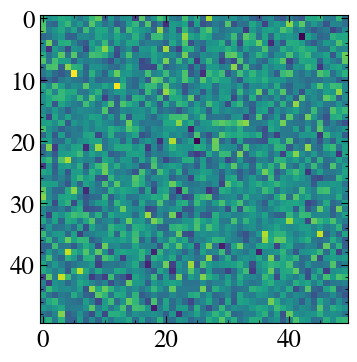

In [67]:
plt.imshow(delta50.preview(axes=[0,1]))

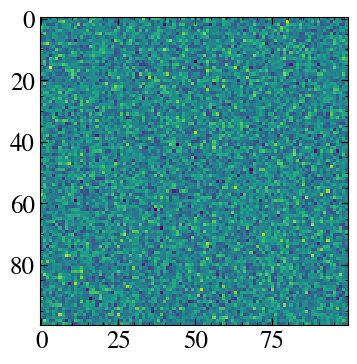

In [41]:
plt.imshow(one_plus_delta.preview(axes=[0,1]))
plt.imshow